# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Your Name: Dominic Rueck
## Date: 03/06/2026
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [2]:
#note feature names, we will reduce these
mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()
# rename the column
df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [4]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [5]:
X = pd.get_dummies(X, prefix_sep=" = ")
X.head()

,odor = a,odor = c,odor = f,odor = l,odor = m,odor = n,odor = p,odor = s,odor = y,spore-print-color = b,...,gill-color = k,gill-color = n,gill-color = o,gill-color = p,gill-color = r,gill-color = u,gill-color = w,gill-color = y,bruises = f,bruises = t
0,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


## 5️⃣ Train/test split (Add Code)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


## 6️⃣ Train a small decision tree (Add Code)

In [16]:

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## 7️⃣ Evaluate the model (Add Code)

In [17]:

pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Accuracy: 0.995

Confusion Matrix:
 [[1052    0]
 [  10  969]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1052
           1       1.00      0.99      0.99       979

    accuracy                           1.00      2031
   macro avg       1.00      0.99      1.00      2031
weighted avg       1.00      1.00      1.00      2031



In [18]:
# show how many poisonous mushrooms were correctly classified and how many were incorrectly classified as edible
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly classified as edible): {tn}")
print(f"False Positives (incorrectly classified as edible): {fp}")
print(f"False Negatives (incorrectly classified as poisonous): {fn}")
print(f"True Positives (correctly classified as poisonous): {tp}")

True Negatives (correctly classified as edible): 1052
False Positives (incorrectly classified as edible): 0
False Negatives (incorrectly classified as poisonous): 10
True Positives (correctly classified as poisonous): 969


## 8️⃣ Visualize the decision tree (Add Code)

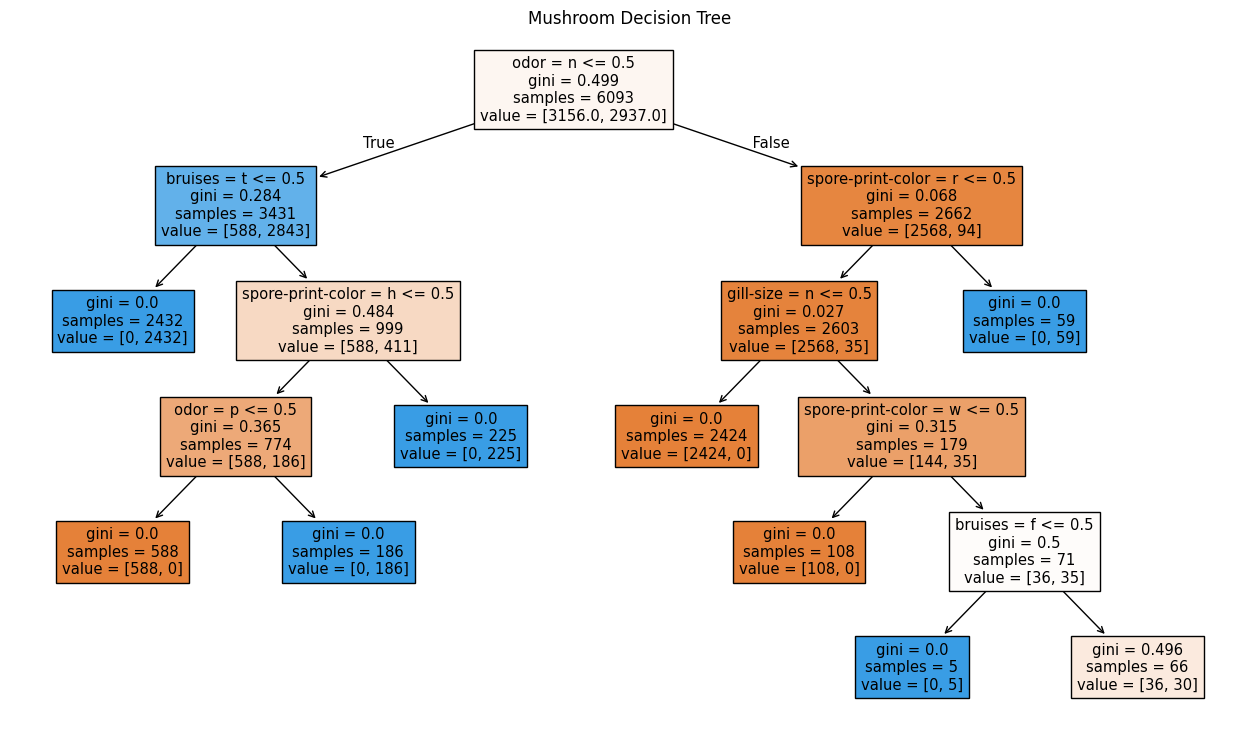

In [19]:

plt.figure(figsize=(16,9))
plot_tree(model, feature_names=X.columns, filled=True)
plt.title("Mushroom Decision Tree")
plt. show()

## 9️⃣ Print IF–THEN rules (Add Code)

In [20]:
print(export_text(model, feature_names=list(X.columns)))

|--- odor = n <= 0.50
|   |--- bruises = t <= 0.50
|   |   |--- class: 1
|   |--- bruises = t >  0.50
|   |   |--- spore-print-color = h <= 0.50
|   |   |   |--- odor = p <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- odor = p >  0.50
|   |   |   |   |--- class: 1
|   |   |--- spore-print-color = h >  0.50
|   |   |   |--- class: 1
|--- odor = n >  0.50
|   |--- spore-print-color = r <= 0.50
|   |   |--- gill-size = n <= 0.50
|   |   |   |--- class: 0
|   |   |--- gill-size = n >  0.50
|   |   |   |--- spore-print-color = w <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- spore-print-color = w >  0.50
|   |   |   |   |--- bruises = f <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- bruises = f >  0.50
|   |   |   |   |   |--- class: 0
|   |--- spore-print-color = r >  0.50
|   |   |--- class: 1



---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy?
   - 96%
2. How many poisonous mushrooms were correctly classified?
   - 896 out of 979 poisonous mushrooms were correctly classified as poisonous.
3. How many poisonous mushrooms were incorrectly predicted as edible?
   - 83 poisonous mushrooms were incorrectly predicted as edible.
5. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one?
   - If someone eats a mushroom that is poisonous, it could lead to servere health problems while if someone skips an edible mushroom, they just mis out on a meal

### Understanding the Tree
5. What feature appears at the **root node**?
   - If the odor = n or not
6. What question is the root node asking in plain English?
   - Is the odor of the mushroom n or not?
7. Describe what the **left branch** and **right branch** mean.
   - The left branch means the odor is n and the right branch means the odor is not n.

### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on?
       - The left node splits on bruises = t and the right splits on spore-print-color = r
   - What question is each node asking?
         - The left node is asking if the mushroom has bruises or not and the right node is asking if the spore-print-color is r or not.
   - What does following the left vs right branch mean?
         - Following the left branch means the mushroom has bruises and following the right branch means the spore-print-color is r.

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English.
    - If the odor is n and the mushroom has bruises, then it is poisonous.
10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous?
    - The most important feature seems to be the odor of the mushroom.

### Exploration
11. Change `max_depth` to 2. What changed?
    - The tree is smaller and only has the root node and the two nodes directly below it. It is less accurate but easier to interpret.
12. Change `max_depth` to 5. What changed?
    - The tree is larger and has more nodes. It is almost perfectly accurate but harder to interpret and probably overfitting the training data.
